In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import figurefirst as fifi
from sklearn.preprocessing import MinMaxScaler

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


In [2]:
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 6
plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'

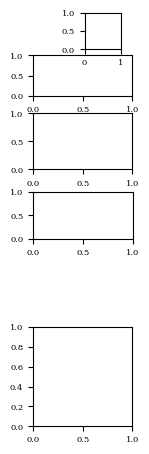

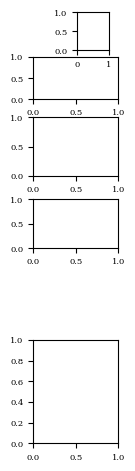

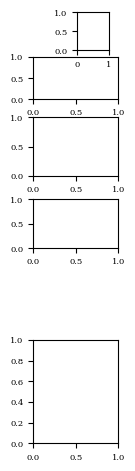

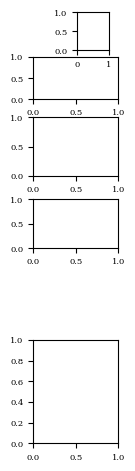

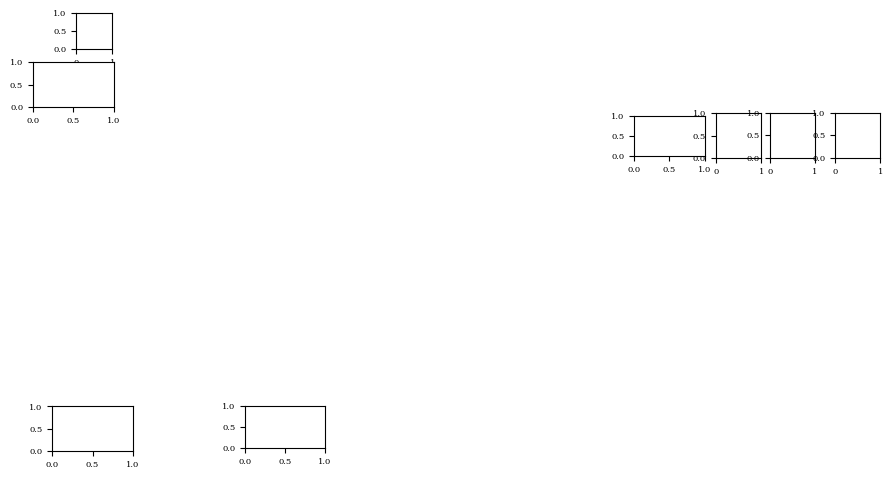

In [4]:
layout = fifi.svg_to_axes.FigureLayout('../unifying_math.svg',autogenlayers=True, make_mplfigures=True, hide_layers=[])

In [5]:
df = pd.read_parquet('../../../../../Data/Fig1_Input_Data/misc/basic_plotting_examples/example_trajectories.parquet')

In [6]:
def plot_trajectory(df, target_obj_id,  ax=None,savefig=False ):
    orig_traj = df[df.obj_id_unique ==target_obj_id][['x','y']].values
    orig_traj = MinMaxScaler().fit_transform(orig_traj)
    color = df[df.obj_id_unique ==target_obj_id].color.iloc[0]
    
    if ax==None:
        # Create figure
        fig, ax = plt.subplots( figsize=(5,5))
    
        ax.plot(orig_traj[:, 0], orig_traj[:, 1], linewidth=1, color=color, label='Original', alpha=1)
        ax.axis('off')
        ax.set_aspect('equal',)
        plt.show()
    
        if savefig==True:
            fig.savefig(f'plot_obj_{target_obj_id}.svg', transparent=True, bbox_inches='tight')
            print(f"Plot saved as 'plot_obj_{target_obj_id}.svg'")
    else:
       
        ax.plot(orig_traj[:, 0], orig_traj[:, 1], linewidth=1, color=color, alpha=1)
        ax.axis('off')
        ax.set_aspect('equal',)



        return ax



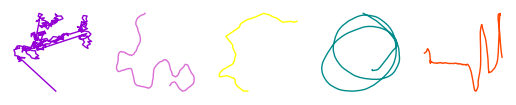

In [7]:
fig, ax= plt.subplots(ncols=5)
#ax[0] = layout.axes[('A1', 'ai1')]
#ax[1] = layout.axes[('A1', 'ai2')]
#ax[2] = layout.axes[('A1', 'ai3')]
#ax[3] = layout.axes[('A1', 'ai4')]
#ax[4] = layout.axes[('A1', 'ai5')]

plot_ids = ['run_and_tumble_959','random_150ms_to_600ms_constant_turns_6783', 'levysmooth_9028','2025-11-16_sink_and_circle_constantwind_131_','2025-11-16_cast_and_surge_constantwind_23769', ]

for i, objid in enumerate(plot_ids):
    plot_trajectory(df, objid,ax=ax[i])


#layout.append_figure_to_layer(layout.figures['A1'], 'A1', cleartarget=True)
